# LSTM

En este cuaderno trabajaremos con redes neuronales LSTM (Long Short-Term Memory), una arquitectura especialmente diseñada para procesar secuencias de datos. Las LSTM son muy útiles cuando el orden de los datos y su contexto a lo largo del tiempo son relevantes, como en el caso de las series temporales

En la bolsa, la secuencia temporal es fundamental porque el valor futuro de una acción depende en gran parte de su evolución pasada.

In [69]:
# Importa las bibliotecas necesarias para hacer una LSTM
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
import pandas as pd

In [70]:
# Leemos el dataset, que descargamos usando la biblioteca yfinance
import yfinance as yf

empresa = 'AMZN'
datos = yf.download(empresa, start='2012-01-01', end='2024-01-01')

# Mostramos una descripción de las columnas
print("Datos descargados: precios diarios de la acción de Amazon (AMZN)")
print("Columnas: Open (apertura), High (máximo), Low (mínimo), Close (cierre), Volume (volumen de negociación)")

# Mostramos las primeras filas del dataset
print(datos.head())

/tmp/ipython-input-70-1456006289.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(empresa, start='2012-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed

Datos descargados: precios diarios de la acción de Amazon (AMZN)
Columnas: Open (apertura), High (máximo), Low (mínimo), Close (cierre), Volume (volumen de negociación)
Price        Close    High     Low    Open     Volume
Ticker        AMZN    AMZN    AMZN    AMZN       AMZN
Date                                                 
2012-01-03  8.9515  8.9740  8.7775  8.7945  102216000
2012-01-04  8.8755  9.0250  8.8035  8.9605   84104000
2012-01-05  8.8805  8.9125  8.7025  8.7970   76182000
2012-01-06  9.1305  9.2325  8.8750  8.9035  140168000
2012-01-09  8.9280  9.2185  8.8500  9.1380  101138000


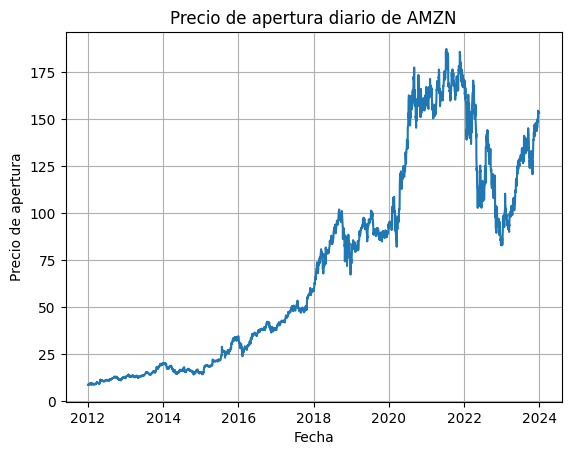

Ticker        AMZN
Date              
2012-01-03  8.7945
2012-01-04  8.9605
2012-01-05  8.7970
2012-01-06  8.9035
2012-01-09  9.1380


In [71]:
# Nos quedamos con los datos de apertura ('Open') y los visualizamos
datos = datos['Open']
plt.plot(datos)
plt.title('Precio de apertura diario de AMZN')
plt.xlabel('Fecha')
plt.ylabel('Precio de apertura')
plt.grid(True)
plt.show()

# Mostramos las primeras filas
print(datos.head())

In [72]:
# Normalizamos los datos
scaler = MinMaxScaler()
datos_array = np.array(datos)
datos_escalades = scaler.fit_transform(datos_array.reshape(-1, 1))

print("Datos más antiguos normalizados:")
print(datos_escalades[0:5])

print("Datos más recientes normalizados:")
print(datos_escalades[-5:])

Datos más antiguos normalizados:
[[0.0005826 ]
 [0.00151252]
 [0.00059661]
 [0.00119321]
 [0.00250687]]
Datos más recientes normalizados:
[[0.81272709]
 [0.81155065]
 [0.81155065]
 [0.81244698]
 [0.8089738 ]]


In [73]:
# Dividimos las muestras en entrenamiento y test
tamaño_entrenamiento = int(len(datos_escalades) * 0.8)
tamaño_test = len(datos_escalades) - tamaño_entrenamiento

datos_entrenamiento = datos_escalades[0:tamaño_entrenamiento, :]
datos_test = datos_escalades[tamaño_entrenamiento:, :1]

In [74]:
"""Una serie temporal es una secuencia de datos ordenados cronológicamente.
En este contexto, representa los precios de apertura de la acción AMZN día tras día.
El orden importa porque cada valor depende del anterior.

El 10 que aparece en longitud_serie = 10 significa que vamos a usar 10 días
consecutivos para predecir el siguiente día.
"""
# Creamos pequeñas series temporales para entrenar y evaluar
def crear_series_temporales(datos, longitud_serie):
    X, Y = [], []
    for i in range(len(datos) - longitud_serie - 1):
        serie_X = datos[i:(i + longitud_serie)]  # Secuencia de datos hasta el momento actual
        serie_Y = datos[i + longitud_serie]      # Valor siguiente a predecir
        X.append(serie_X)
        Y.append(serie_Y)
    return np.array(X), np.array(Y)

longitud_serie = 10  # Longitud de la ventana temporal
X_train, y_train = crear_series_temporales(datos_entrenamiento, longitud_serie)
X_test, y_test = crear_series_temporales(datos_test, longitud_serie)

print("Los datos de entrenamiento tienen la forma {}".format(X_train.shape))
print("Los valores a predecir en entrenamiento (y) tienen la forma {}".format(y_train.shape))
print("Los datos de test tienen la forma {}".format(X_test.shape))
print("Los valores a predecir en test (y) tienen la forma {}".format(y_test.shape))

Los datos de entrenamiento tienen la forma (2403, 10, 1)
Los valores a predecir en entrenamiento (y) tienen la forma (2403, 1)
Los datos de test tienen la forma (593, 10, 1)
Los valores a predecir en test (y) tienen la forma (593, 1)


In [75]:
# Definimos y compilamos el modelo LSTM
# La LSTM recibirá secuencias de 10 días, y en cada día solo se le dará un valor: el precio de apertura normalizado
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [76]:
# Entrenamos el modelo
model.fit(X_train, y_train, epochs=10, batch_size=64, verbose=1)

# Evaluamos el modelo
train_loss = model.evaluate(X_train, y_train, verbose=0)
test_loss = model.evaluate(X_test, y_test, verbose=0)

print('Pérdida en entrenamiento:', train_loss)
print('Pérdida en test:', test_loss)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1301
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0014
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.3257e-04
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.8358e-04
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.8390e-04
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.7681e-04
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 1.7323e-04
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.6782e-04
Epoch 9/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.6588e-04
Epoch 10/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.5646e-04
Pérdida en entrenamiento: 0.0001627192978048697
Pérdida en test: 0.0007797291036695242


In [77]:
# Usamos el modelo entrenado con AMZN para hacer predicciones finales
predicciones_train = model.predict(X_train)
predicciones_test = model.predict(X_test)

# Desnormalizamos las predicciones para volver a los valores reales
predicciones_train = scaler.inverse_transform(predicciones_train)
predicciones_test = scaler.inverse_transform(predicciones_test)

# Creamos DataFrames con el índice original de fechas
predicciones_train = pd.DataFrame(predicciones_train, index=datos.index[:len(predicciones_train)])
predicciones_test = pd.DataFrame(predicciones_test, index=datos.index[len(datos) - len(predicciones_test):])

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


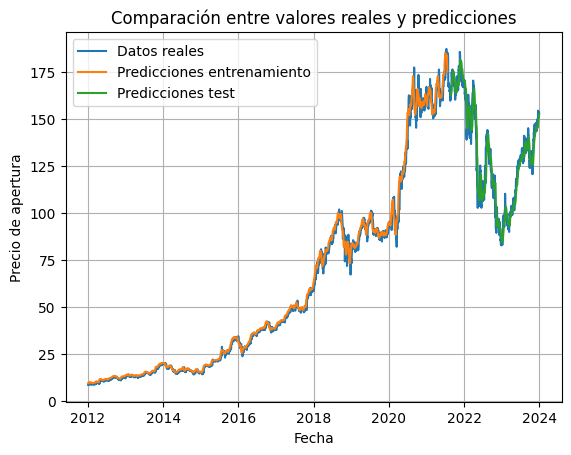

In [78]:
# Gráfico de todas las predicciones
plt.plot(datos, label='Datos reales')
plt.plot(predicciones_train, label='Predicciones entrenamiento')
plt.plot(predicciones_test, label='Predicciones test')
plt.legend()
plt.title('Comparación entre valores reales y predicciones')
plt.xlabel('Fecha')
plt.ylabel('Precio de apertura')
plt.grid(True)
plt.show()

In [79]:
# Evaluamos el modelo entrenado con AMZN sobre sus propios datos
train_loss = model.evaluate(X_train, y_train, verbose=0)
test_loss = model.evaluate(X_test, y_test, verbose=0)

print('Pérdida en entrenamiento:', train_loss)
print('Pérdida en test:', test_loss)

Pérdida en entrenamiento: 0.0001627192978048697
Pérdida en test: 0.0007797291036695242


In [80]:
# Extraer los últimos 10 valores del precio de apertura
ultimos_dias = datos[-10:].values

# Mostrar el último valor real (día más reciente)
print("Último valor real observado:", round(ultimos_dias[-1][0], 4))

# Convertir a float32 y reshape a (10, 1)
ultimos_dias = ultimos_dias.astype(np.float32).reshape(-1, 1)

# Normalizar
entrada_normalizada = scaler.transform(ultimos_dias)

# Reshape a (1, 10, 1) para la LSTM
entrada_lstm = entrada_normalizada.reshape(1, 10, 1).astype(np.float32)

# Predicción
prediccion_normalizada = model.predict(entrada_lstm, verbose=0)
print("Predicción normalizada:", prediccion_normalizada)

# Desnormalizar
prediccion_final = scaler.inverse_transform(prediccion_normalizada)
print("Próximo valor predicho:", round(prediccion_final[0][0], 4))

Último valor real observado: 153.1
Predicción normalizada: [[0.80749273]]
Próximo valor predicho: 152.8356
